# LAB-D2-02 SOLUTION: Backpropagation and Gradient Check

**INSTRUCTOR ONLY - DO NOT DISTRIBUTE WITH PARTICIPANT MATERIALS**

**Objectives:** `OBJ-D2-04`, with reinforcement of `OBJ-D2-02` and `OBJ-D2-03`  
**Reference environment:** local CPU; Python 3.11+; NumPy float64 and matplotlib; no network or GPU  
**Expected compute runtime:** under 10 seconds  
**Execution contract:** Clear outputs, restart the kernel, and run all cells from top to bottom.

This completed solution keeps each participant claim independently testable: qualitative signs,
analytic formulas, central finite differences, structured defects, a loss-lowering update, and a
single-parameter perturbation. Stored numeric evidence is deterministic for the supplied arrays.

In [1]:
import copy
import platform

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

np.set_printoptions(precision=8, suppress=True)
plt.rcParams.update({"figure.figsize": (9, 5), "axes.grid": True, "grid.alpha": 0.22})
print(f"Python {platform.python_version()} | NumPy {np.__version__} | matplotlib {matplotlib.__version__}")
print("Runtime target: local/Colab CPU; float64 gradient checks; no GPU required.")

Python 3.11.8 | NumPy 2.4.6 | matplotlib 3.11.1
Runtime target: local/Colab CPU; float64 gradient checks; no GPU required.


## Recap: Local Sensitivity Times Upstream Gradient

A forward pass stores values. A backward pass reuses those values while carrying sensitivity from loss toward earlier parameters. At each node:

$$\text{downstream sensitivity}=\text{upstream sensitivity}\times\text{local derivative}$$

A gradient is a local rate of change. It is not causal blame, global feature importance, or evidence that the objective itself is appropriate.

## Local Dataset and Fixed `2 -> 2 -> 1` Network

One example has two input features and one binary target. Examples are rows. Both hidden units and the output use sigmoid. Every value is float64 so central finite differences can serve as a precise independent check.

In [2]:
X = np.array([[0.6, -1.2]], dtype=np.float64)
y = np.array([[1.0]], dtype=np.float64)
parameters = {
    "W1": np.array([[0.2, -0.4], [0.7, 0.3]], dtype=np.float64),
    "b1": np.array([0.1, -0.2], dtype=np.float64),
    "W2": np.array([[0.5], [-0.6]], dtype=np.float64),
    "b2": np.array([0.05], dtype=np.float64),
}
assert X.shape == (1, 2) and y.shape == (1, 1)
assert parameters['W1'].shape == (2, 2) and parameters['b1'].shape == (2,)
assert parameters['W2'].shape == (2, 1) and parameters['b2'].shape == (1,)
assert all(value.dtype == np.float64 for value in [X, y, *parameters.values()])
print("Fixed example and parameter shapes ready.")

Fixed example and parameter shapes ready.


## Predict Signs Before Arithmetic

Without calculating exact values, predict whether a small increase to each selected parameter raises or lowers loss. Use the path from that parameter to the output, the target `1`, and the current signs of downstream weights. State a sign for `dL/dW2[0,0]`, `dL/dW2[1,0]`, `dL/db2[0]`, `dL/dW1[0,0]`, and `dL/dW1[0,1]`. Mark the least-certain path.

### Instructor Hint Ladder: Sign Paths

(1) For target `1`, decide the sign of `P-y`. (2) Hidden activations are positive, so they do not
flip output-weight signs. (3) Propagate through each signed `W2` entry. (4) Only then include the
input feature sign. Ask for the least-certain path before revealing arithmetic.

**Likely misconception:** A positive weight must have a positive gradient. The gradient sign depends
on the full local path and current target mismatch, not the parameter sign alone.

In [3]:
sign_predictions = {
    "dW2_0_0": "negative",
    "dW2_1_0": "negative",
    "db2_0": "negative",
    "dW1_0_0": "negative",
    "dW1_0_1": "positive",
    "least_certain_path_and_reason": "dW1[0,1]: its sign passes through the output error, negative W2[1,0], the hidden sigmoid derivative, and positive X[0,0].",
}
assert all(value.strip() for value in sign_predictions.values()), (
    "Prediction checkpoint: record every sign and one path reason before the forward reveal."
)
print("Instructor sign predictions:", sign_predictions)

Instructor sign predictions: {'dW2_0_0': 'negative', 'dW2_1_0': 'negative', 'db2_0': 'negative', 'dW1_0_0': 'negative', 'dW1_0_1': 'positive', 'least_certain_path_and_reason': 'dW1[0,1]: its sign passes through the output error, negative W2[1,0], the hidden sigmoid derivative, and positive X[0,0].'}


## Modify: Build the Manual Forward Cache

Complete stable sigmoid, clipped BCE, and `forward`. The cache must contain `X`, `Z1`, `A1`, `Z2`, and `P`. Preserve the shapes shown by the network contract.

In [4]:
def sigmoid(values):
    values = np.asarray(values, dtype=np.float64)
    output = np.empty_like(values)
    nonnegative = values >= 0
    output[nonnegative] = 1.0 / (1.0 + np.exp(-values[nonnegative]))
    exp_values = np.exp(values[~nonnegative])
    output[~nonnegative] = exp_values / (1.0 + exp_values)
    return output

def binary_cross_entropy(y_true, probabilities, epsilon=1e-12):
    y_true = np.asarray(y_true, dtype=np.float64)
    probabilities = np.asarray(probabilities, dtype=np.float64)
    clipped = np.clip(probabilities, epsilon, 1.0 - epsilon)
    return float(np.mean(-(y_true * np.log(clipped) + (1.0 - y_true) * np.log(1.0 - clipped))))

def forward(X, parameters):
    Z1 = X @ parameters['W1'] + parameters['b1']
    A1 = sigmoid(Z1)
    Z2 = A1 @ parameters['W2'] + parameters['b2']
    P = sigmoid(Z2)
    return {"X": X, "Z1": Z1, "A1": A1, "Z2": Z2, "P": P}

In [5]:
cache = forward(X, parameters)
initial_loss = binary_cross_entropy(y, cache['P'])
assert cache['Z1'].shape == cache['A1'].shape == (1, 2)
assert cache['Z2'].shape == cache['P'].shape == (1, 1)
assert np.all(np.isfinite([initial_loss, *cache['Z1'].ravel(), *cache['A1'].ravel(), *cache['Z2'].ravel(), *cache['P'].ravel()]))
print(f"{'node':<6} {'shape':<10} values")
for name in ['X', 'Z1', 'A1', 'Z2', 'P']:
    print(f"{name:<6} {str(cache[name].shape):<10} {cache[name].ravel()}")
print(f"Loss: {initial_loss:.8f}")

node   shape      values
X      (1, 2)     [ 0.6 -1.2]
Z1     (1, 2)     [-0.62 -0.8 ]
A1     (1, 2)     [0.34978145 0.31002552]
Z2     (1, 1)     [0.03887541]
P      (1, 1)     [0.50971763]
Loss: 0.67389837


### Instructor Reveal: Forward Evidence

The clean initial loss is approximately `0.67389837`. Preserve `(B,1)` at the output; squeezing to
`(B,)` can conceal later broadcasting errors. Stable sigmoid variants are acceptable if they preserve
shape, dtype, and finite values.

## Inspect: Forward Values on the Computational Graph

The graph shows one relationship: values move forward through affine and sigmoid operations. After backpropagation, you will add signed sensitivities to the same stages. Node width is not parameter importance.

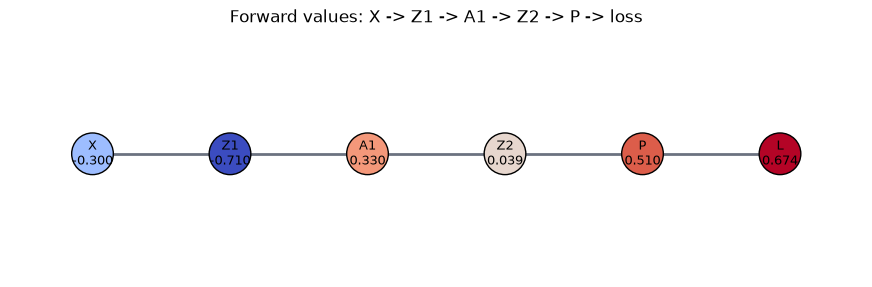

In [6]:
node_names = ['X', 'Z1', 'A1', 'Z2', 'P', 'L']
node_x = np.arange(len(node_names))
node_values = [X.mean(), cache['Z1'].mean(), cache['A1'].mean(), cache['Z2'].item(), cache['P'].item(), initial_loss]
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(node_x, np.zeros_like(node_x), color='#6b7280', linewidth=2, zorder=1)
ax.scatter(node_x, np.zeros_like(node_x), c=node_values, cmap='coolwarm', s=900, edgecolor='black', zorder=2)
for x_pos, name, value in zip(node_x, node_names, node_values):
    ax.text(x_pos, 0.0, f"{name}\n{value:.3f}", ha='center', va='center', fontsize=9, zorder=3)
ax.set(xlim=(-0.6, len(node_names) - 0.4), ylim=(-0.7, 0.7), title='Forward values: X -> Z1 -> A1 -> Z2 -> P -> loss')
ax.axis('off')
plt.show()

## Modify: Manual Backpropagation

Complete `backward`. For sigmoid output with BCE, begin with `dZ2 = (P - y) / B`. Continue through `W2`, apply the hidden sigmoid local derivative, and return gradients with keys matching the parameter dictionary. Do not loop over parameters or examples.

### Instructor Hint Ladder: Backward Trace

(1) Start with the supplied `dZ2`. (2) Match each matrix product to its parameter shape. (3) Carry
`dA1` through `W2.T`. (4) Apply `A1*(1-A1)` before computing layer-1 parameter gradients. A shape
table is a better hint than writing the formula for participants.

In [7]:
def backward(cache, parameters, y_true):
    batch_size = y_true.shape[0]
    dZ2 = (cache['P'] - y_true) / batch_size
    dW2 = cache['A1'].T @ dZ2
    db2 = dZ2.sum(axis=0)
    dA1 = dZ2 @ parameters['W2'].T
    dZ1 = dA1 * cache['A1'] * (1.0 - cache['A1'])
    dW1 = cache['X'].T @ dZ1
    db1 = dZ1.sum(axis=0)
    return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}

In [8]:
analytic_gradients = backward(cache, parameters, y)
assert set(analytic_gradients) == set(parameters)
for name in parameters:
    assert analytic_gradients[name].shape == parameters[name].shape
    assert np.all(np.isfinite(analytic_gradients[name]))
print(f"{'parameter':<10} {'gradient shape':<16} {'gradient values'}")
for name, gradient in analytic_gradients.items():
    print(f"{name:<10} {str(gradient.shape):<16} {gradient.ravel()}")

parameter  gradient shape   gradient values
W1         (2, 2)           [-0.03345212  0.03775542  0.06690424 -0.07551083]
b1         (2,)             [-0.05575354  0.06292569]
W2         (2, 1)           [-0.17149168 -0.15200005]
b2         (1,)             [-0.49028237]


## Check: Central Finite Differences

The supplied harness perturbs one scalar parameter at a time by `+epsilon` and `-epsilon`, then estimates slope from the two losses. It is a testing instrument, not the training algorithm. Predict what a small relative error would support and what it cannot establish about model usefulness.

In [9]:
gradient_check_prediction = {
    "small_error_supports": "The manual backward formulas are locally consistent with independently perturbed forward losses for the checked parameters.",
    "small_error_does_not_establish": "It does not establish that the task, data, architecture, loss, or learned model is useful, nor prove correctness away from these values.",
}
assert all(value.strip() for value in gradient_check_prediction.values())
print("Instructor gradient-check interpretation:", gradient_check_prediction)

Instructor gradient-check interpretation: {'small_error_supports': 'The manual backward formulas are locally consistent with independently perturbed forward losses for the checked parameters.', 'small_error_does_not_establish': 'It does not establish that the task, data, architecture, loss, or learned model is useful, nor prove correctness away from these values.'}


In [10]:
def finite_difference_gradients(X, y_true, parameters, epsilon=1e-6):
    numerical = {}
    for name, values in parameters.items():
        numerical[name] = np.zeros_like(values)
        for index in np.ndindex(values.shape):
            plus = {key: value.copy() for key, value in parameters.items()}
            minus = {key: value.copy() for key, value in parameters.items()}
            plus[name][index] += epsilon
            minus[name][index] -= epsilon
            loss_plus = binary_cross_entropy(y_true, forward(X, plus)['P'])
            loss_minus = binary_cross_entropy(y_true, forward(X, minus)['P'])
            numerical[name][index] = (loss_plus - loss_minus) / (2.0 * epsilon)
    return numerical

def relative_error(analytic, numerical):
    numerator = np.abs(analytic - numerical)
    denominator = np.maximum(1e-12, np.abs(analytic) + np.abs(numerical))
    return numerator / denominator

numerical_gradients = finite_difference_gradients(X, y, parameters)
gradient_check_rows = []
for name in parameters:
    errors = relative_error(analytic_gradients[name], numerical_gradients[name])
    gradient_check_rows.append((name, float(np.max(errors))))
    print(f"{name:<4} max relative error = {np.max(errors):.3e}")
max_relative_error = max(error for _, error in gradient_check_rows)
assert max_relative_error < 1e-5

W1   max relative error = 1.012e-09
b1   max relative error = 3.657e-10
W2   max relative error = 1.611e-10
b2   max relative error = 7.912e-11


### Instructor Reveal: Gradient-Check Range

The reference maximum relative error is about `1.0e-9`, comfortably below the `1e-5` checkpoint.
Treat the threshold as a sanity invariant, not a grading contest for the smallest decimal. A correct
forward function shared by both analytic and numerical paths can still hide a conceptual model error.

## Model Detective: Two Structured Backward Bugs

Before seeing faulty source, predict the relative-error pattern for two cases: (1) the output error sign is reversed, and (2) the hidden sigmoid factor is omitted. For each case, state whether output-layer gradients, hidden-layer gradients, or both should disagree with finite differences.

### Instructor Hint Ladder: Defect Localization

(1) Check one output-layer scalar and one hidden-layer scalar. (2) Ask where the omitted factor first
enters the graph. (3) Distinguish a global upstream sign reversal from a local hidden derivative.
Reveal the faulty source only after a layer-pattern prediction.

In [11]:
bug_pattern_predictions = {
    "sign_bug_output_layer": "W2 and b2 should disagree because dZ2 is reversed.",
    "sign_bug_hidden_layer": "W1 and b1 should also disagree because the reversed upstream gradient propagates backward.",
    "missing_factor_output_layer": "W2 and b2 should still agree because they are computed before the hidden sigmoid derivative is needed.",
    "missing_factor_hidden_layer": "W1 and b1 should disagree because dZ1 omits A1*(1-A1).",
    "cheapest_discriminating_check": "Compare one output scalar such as W2[0,0] and one hidden scalar such as W1[0,0] against finite differences.",
}
assert all(value.strip() for value in bug_pattern_predictions.values())
print("Instructor defect predictions recorded.")

Instructor defect predictions recorded.


In [12]:
def faulty_backward(cache, parameters, y_true, defect):
    B = y_true.shape[0]
    dZ2 = (cache['P'] - y_true) / B
    if defect == 'sign':
        dZ2 = -dZ2
    dW2 = cache['A1'].T @ dZ2
    db2 = dZ2.sum(axis=0)
    dA1 = dZ2 @ parameters['W2'].T
    dZ1 = dA1 if defect == 'missing_hidden_sigmoid_factor' else dA1 * cache['A1'] * (1.0 - cache['A1'])
    return {"W1": cache['X'].T @ dZ1, "b1": dZ1.sum(axis=0), "W2": dW2, "b2": db2}

bug_evidence = {}
for defect in ['sign', 'missing_hidden_sigmoid_factor']:
    gradients = faulty_backward(cache, parameters, y, defect)
    bug_evidence[defect] = {name: float(np.max(relative_error(gradients[name], numerical_gradients[name]))) for name in parameters}

print(f"{'defect':<32} {'W1':>10} {'b1':>10} {'W2':>10} {'b2':>10}")
for defect, errors in bug_evidence.items():
    print(f"{defect:<32} {errors['W1']:>10.3e} {errors['b1']:>10.3e} {errors['W2']:>10.3e} {errors['b2']:>10.3e}")
assert max(bug_evidence['sign'].values()) > 1e-2
assert max(bug_evidence['missing_hidden_sigmoid_factor']['W1'], bug_evidence['missing_hidden_sigmoid_factor']['b1']) > 1e-2
assert max(bug_evidence['missing_hidden_sigmoid_factor']['W2'], bug_evidence['missing_hidden_sigmoid_factor']['b2']) < 1e-5

defect                                   W1         b1         W2         b2
sign                              1.000e+00  1.000e+00  1.000e+00  1.000e+00
missing_hidden_sigmoid_factor     6.476e-01  6.476e-01  1.611e-10  7.912e-11


## Diagnose and Repair the Local Rule

For each evidence row, cite which layers agree or disagree, identify the violated local rule, and write the targeted expression that restores the invariant. Explain why the missing hidden factor does not corrupt `W2` or `b2` in this graph.

In [13]:
bug_diagnosis = {
    "sign_bug_evidence": "All four groups have large relative error (approximately 1.0), consistent with a globally reversed upstream sign.",
    "sign_bug_repair_expression": "Restore dZ2 = (P - y_true) / B.",
    "missing_factor_evidence": "W1 and b1 fail strongly (about 0.648), while W2 and b2 remain near finite-difference precision.",
    "missing_factor_repair_expression": "Restore dZ1 = dA1 * A1 * (1 - A1).",
    "why_output_layer_is_unchanged": "dW2 and db2 depend on A1 and dZ2; the hidden sigmoid derivative is required only after dA1 is propagated toward layer 1.",
}
assert all(value.strip() for value in bug_diagnosis.values())
print("Instructor bug diagnosis:", bug_diagnosis)

Instructor bug diagnosis: {'sign_bug_evidence': 'All four groups have large relative error (approximately 1.0), consistent with a globally reversed upstream sign.', 'sign_bug_repair_expression': 'Restore dZ2 = (P - y_true) / B.', 'missing_factor_evidence': 'W1 and b1 fail strongly (about 0.648), while W2 and b2 remain near finite-difference precision.', 'missing_factor_repair_expression': 'Restore dZ1 = dA1 * A1 * (1 - A1).', 'why_output_layer_is_unchanged': 'dW2 and db2 depend on A1 and dZ2; the hidden sigmoid derivative is required only after dA1 is propagated toward layer 1.'}


## Update Check: Move in the Negative-Gradient Direction

Predict whether one small simultaneous update should lower this fixed example's loss. Complete `apply_gradients` without mutating the original parameter dictionary, then compare before and after. This local decrease does not guarantee every future batch or metric will improve.

In [14]:
update_prediction = {
    "loss_direction": "A sufficiently small simultaneous negative-gradient update should lower this fixed example's loss.",
    "scope_limit": "The local result does not guarantee lower loss for every future batch, a larger step, another metric, or validation data.",
}
assert all(value.strip() for value in update_prediction.values())

def apply_gradients(parameters, gradients, learning_rate):
    return {
        name: values - learning_rate * gradients[name]
        for name, values in parameters.items()
    }

In [15]:
parameter_snapshot = {name: value.copy() for name, value in parameters.items()}
updated_parameters = apply_gradients(parameters, analytic_gradients, learning_rate=0.1)
updated_loss = binary_cross_entropy(y, forward(X, updated_parameters)['P'])
print(f"Loss before: {initial_loss:.8f}")
print(f"Loss after one negative-gradient update: {updated_loss:.8f}")
assert updated_loss < initial_loss
assert all(np.array_equal(parameters[name], parameter_snapshot[name]) for name in parameters)

Loss before: 0.67389837
Loss after one negative-gradient update: 0.64313799


### Instructor Reveal: Update Evidence

The clean reference loss falls from about `0.67389837` to `0.64313799` at learning rate `0.1`.
This demonstrates local descent for this point and step; it does not upgrade a gradient check into a
general convergence guarantee.

## Challenge: One-Parameter Perturbation Test

Choose one scalar parameter and a signed perturbation of magnitude `1e-3`. Predict the loss direction from your analytic gradient before running. Change only that scalar in a copy, then reconcile the observed loss change with `gradient * perturbation`.

In [16]:
challenge_parameter = "W2"
challenge_index = (0, 0)
challenge_delta = 1e-3
challenge_prediction = "dL/dW2[0,0] is negative, so a positive perturbation should reduce loss."
assert challenge_parameter in parameters and isinstance(challenge_index, tuple)
assert challenge_delta is not None and np.isclose(abs(challenge_delta), 1e-3)
assert challenge_prediction.strip()
challenge_parameters = {name: value.copy() for name, value in parameters.items()}
challenge_parameters[challenge_parameter][challenge_index] += challenge_delta
challenge_loss = binary_cross_entropy(y, forward(X, challenge_parameters)['P'])
first_order_change = analytic_gradients[challenge_parameter][challenge_index] * challenge_delta
print(f"Observed loss change: {challenge_loss - initial_loss:+.8e}")
print(f"First-order gradient prediction: {first_order_change:+.8e}")
challenge_interpretation = (
    "Observed and first-order changes are both negative and nearly equal. The small difference is "
    "higher-order curvature omitted by the local linear approximation."
)
assert challenge_interpretation.strip()
print("Instructor interpretation:", challenge_interpretation)

Observed loss change: -1.71476391e-04
First-order gradient prediction: -1.71491679e-04
Instructor interpretation: Observed and first-order changes are both negative and nearly equal. The small difference is higher-order curvature omitted by the local linear approximation.


## Optional Extension: Finite-Difference Epsilon Sweep

Predict why extremely large and extremely small epsilon values can both weaken a numerical gradient check. Sweep the supplied values for one selected scalar and plot relative error. This extension is independent of the core checkpoint.

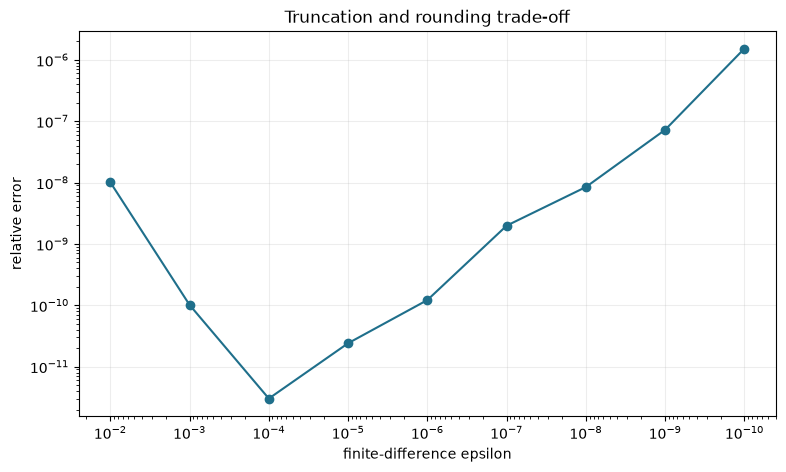

Instructor epsilon interpretation: The useful region bottoms out near epsilon=1e-04 in this run. Larger values average over curvature; smaller values subtract nearly equal losses and amplify rounding.


In [17]:
optional_parameter = "W2"
optional_index = (0, 0)
optional_prediction = "Large epsilon adds truncation error; extremely small epsilon suffers cancellation and floating-point rounding."
if optional_parameter is None or optional_index is None or not optional_prediction.strip():
    print("Optional epsilon sweep skipped. Core checkpoint is unaffected.")
else:
    epsilons = np.logspace(-2, -10, 9)
    errors = []
    for epsilon in epsilons:
        estimate = finite_difference_gradients(X, y, parameters, epsilon)[optional_parameter][optional_index]
        analytic_value = analytic_gradients[optional_parameter][optional_index]
        errors.append(float(relative_error(np.array(analytic_value), np.array(estimate))))
    fig, ax = plt.subplots()
    ax.loglog(epsilons, errors, marker='o', color='#1f6f8b')
    ax.set(xlabel='finite-difference epsilon', ylabel='relative error', title='Truncation and rounding trade-off')
    ax.invert_xaxis()
    plt.show()
    best_epsilon = float(epsilons[int(np.argmin(errors))])
    optional_interpretation = (
        f"The useful region bottoms out near epsilon={best_epsilon:.0e} in this run. Larger values "
        "average over curvature; smaller values subtract nearly equal losses and amplify rounding."
    )
    assert optional_interpretation.strip()
    print("Instructor epsilon interpretation:", optional_interpretation)

## Reflect and Checkpoint

Explain how sign prediction, analytic/numerical agreement, structured bug patterns, and the negative-gradient update test different claims. State one situation where finite differences could mislead and why backpropagation reuses local work more efficiently.

### Instructor Debrief and Delivery Notes

**Discussion triggers:** Why can output gradients pass while hidden gradients fail? Why is a numerical
check not the training algorithm? Which check would catch a wrong update sign after a correct backward?

**Common failures:** Float32 or forward saturation can weaken the check; mutating the parameter
dictionary corrupts comparisons; running the defect cell before numerical gradients creates an order
error; squeezing the output changes the shape contract. CPU and Colab should agree within the broad
`<1e-5` band, though the last digits of the epsilon sweep may differ.

**Fast recovery:** If the optional plot fails, report the error table and identify the middle useful
region. If time is short, check one scalar from `W2` and one from `W1`, then run the full harness later.

**Acceptable alternatives:** Any stable sigmoid, central-difference helper, scalar challenge, or epsilon
choice is valid when it preserves float64, non-mutation, shape, and the stated interpretation limits.

In [18]:
reflection = {
    "four_checks_test_different_claims": "Sign prediction tests conceptual direction; finite differences test local formula agreement; bug patterns localize violated rules; the update tests whether the assembled gradient produces a local loss decrease.",
    "finite_difference_limit": "Saturation, non-smooth points, poor epsilon, low precision, or inconsistent mutation can make numerical checks misleading even when code looks plausible.",
    "backprop_reuse": "Backprop caches forward values and reuses each node's local derivative and upstream sensitivity, avoiding a separate forward perturbation for every scalar parameter.",
}
assert all(value.strip() for value in reflection.values())
assert max_relative_error < 1e-5
assert updated_loss < initial_loss
assert max(bug_evidence['sign'].values()) > 1e-2
assert max(bug_evidence['missing_hidden_sigmoid_factor']['W1'], bug_evidence['missing_hidden_sigmoid_factor']['b1']) > 1e-2
assert max(bug_evidence['missing_hidden_sigmoid_factor']['W2'], bug_evidence['missing_hidden_sigmoid_factor']['b2']) < 1e-5
print("LAB-D2-02 checkpoint passed: float64 cache, gradient agreement, distinct bug signatures, and loss-lowering update.")

LAB-D2-02 checkpoint passed: float64 cache, gradient agreement, distinct bug signatures, and loss-lowering update.


## Takeaways

- Backpropagation composes local derivatives with upstream sensitivity.
- Predicting signs exposes conceptual errors before detailed arithmetic.
- Central finite differences make the backward pass a falsifiable claim.
- Layer-local mismatch patterns help locate missing factors.
- `backward` computes gradients; a separate negative-gradient update changes parameters.

## Troubleshooting

| Symptom | Likely cause | Recovery |
|---|---|---|
| Output shapes become `(1,)` | A bias or probability was squeezed | Preserve `(B, 1)` through the binary output |
| Every analytic gradient has opposite sign | `P - y` was reversed | Recheck the BCE-with-sigmoid output derivative |
| Only `W1` and `b1` fail | Hidden sigmoid local derivative is missing | Multiply `dA1` by `A1 * (1 - A1)` |
| Relative error is large everywhere | Forward loss or parameter copy is inconsistent | Check float64, central differences, and non-mutating perturbations |
| Relative error worsens at tiny epsilon | Floating-point cancellation dominates | Return to the supplied calibrated epsilon |
| One update raises loss | Update sign or rate is wrong | Verify subtraction and retry the supplied small rate |

## Continue

Return to the [LAB-D2-02 debrief](../student-guide/day-2-student-guide.md#lab-d2-02---backpropagation-and-gradient-check). Review [LESSON-D2-03](../student-guide/day-2-student-guide.md#lesson-d2-03---computational-graphs-and-backpropagation), [ACT-D2-02](../challenges/day-2-challenges.md#act-d2-02---learning-rate-trajectory-and-gradient-sign), and [LAB-D2-01](LAB-D2-01-loss-learning-rate.ipynb) as needed.